# Cetrnioles tracking

## Dataset: 4-6 hpf Cetn2:GFP & CS 

In this scipt, I regoup my investigation about centrioles tracking.

In [115]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
from pathlib import Path
import btrack

import trackpy as tp
import btrack

import warnings

import sys

my_path = Path.cwd().parent.parent / "src"
sys.path.append(str(my_path))

from visualization import visualization
from utils import utils

%matplotlib inline

In [116]:

ROOT = Path(r"K:\users\voland\images\cova_data\TgCetnGFP_CenSpark\4-6hpf_CetnGFP_CS\tracking")

VOL_PATH = ROOT/"cropped" /"tracking_20260115CFHa_CetnGFP_CS_TL_4-6hpf_e4_t1-7-1.tif"

C1_BLOB_CENTER_IMG_PATH = ROOT  / "centrioles_detection" / "C1_results" / "C1_detection_img.tif"
C2_BLOB_CENTER_IMG_PATH = ROOT / "centrioles_detection" / "C2_results" / "C2_detection_img.tif"

C1_BLOB_CENTER_PATH = ROOT / "centrioles_detection" / "C1_results" / "C1_centers.csv"
C2_BLOB_CENTER_PATH = ROOT / "centrioles_detection" / "C2_results" / "C2_centers.csv"

C2_PTRACK_IMG_PATH = ROOT / "results" / "C2_results" / "C2_pytrack_img.tif"
C2_BTRACK_IMG_PATH = ROOT / "results" / "C2_results" / "C2_btrack_img.h5"

In [135]:
FRAMES = 7
Z_UM = 17.62
Y_UM = 59.02

X_UM =  62.65

resolution = np.array([Z_UM,Y_UM,X_UM])
scale= utils.get_pixel_size(VOL_PATH)
scale

array([0.56839038, 0.15133305, 0.15133305])

## Data loading

In [118]:
vol = tifffile.imread(VOL_PATH)
vol_ct = vol[:,:,0]
vol_cs = vol[:,:,1]
print(vol.shape)

(7, 31, 3, 390, 414)


In [119]:
centers_ct_vol = tifffile.imread(C1_BLOB_CENTER_IMG_PATH)
centers_cs_vol = tifffile.imread(C2_BLOB_CENTER_IMG_PATH)

In [120]:
centers_ct = pd.read_csv(C1_BLOB_CENTER_PATH)
centers_cs = pd.read_csv(C2_BLOB_CENTER_PATH)

For our analyis let's start with the CenSpark channel.

   index    T     Z      Y      X         R        Zum        Yum        Xum  \
0      0  0.0  19.0  218.0  187.0  1.732051  10.799417  32.990604  28.299280   
1      1  0.0   6.0   71.0   64.0  1.732051   3.410342  10.744646   9.685315   
2      2  0.0  18.0   36.0  246.0  1.732051  10.231027   5.447990  37.227930   
3      3  0.0  19.0  189.0   45.0  2.771281  10.799417  28.601946   6.809987   
4      4  0.0  16.0  384.0   79.0  1.732051   9.094246  58.111890  11.955311   

        Rum  
0  0.262117  
1  0.262117  
2  0.262117  
3  0.419386  
4  0.262117  


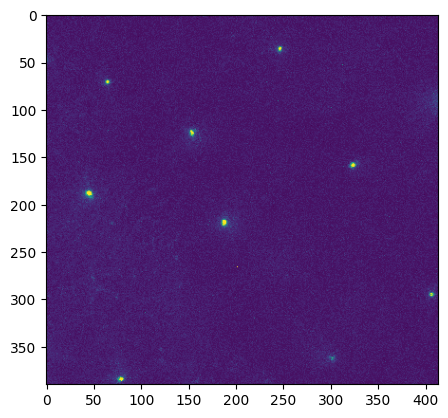

In [121]:
print(centers_cs.head())
t,z,y,x = vol_cs.shape

vol_cs1_max = np.max(vol_cs[0],axis=0)
plt.imshow(vol_cs1_max)

In [122]:
print(f"Avg detections per frame: {len(centers_cs) / centers_cs['T'].nunique():.1f}")

Avg detections per frame: 16.6


## Tracking

### Trackpy
The first method I tried is reported and presented in this [notebook](https://github.com/bnsreenu/python_for_microscopists/blob/master/289_tracking_particles_in_3D.ipynb).

In [123]:
fcenters_cs = centers_cs[["T","Zum","Yum","Xum"]].copy()
fcenters_cs.columns = ["frame","Zum","Yum","Xum"]

Frame 6: 21 trajectories present.


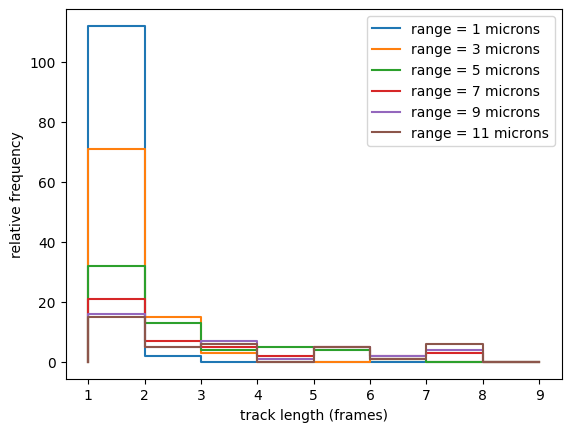

In [124]:
for search_range in range(1,12,2):
    linked = tp.link_df(fcenters_cs, search_range, pos_columns=["Zum","Yum","Xum"])
    hist, bins = np.histogram(np.bincount(linked.particle.astype(int)),
                              bins=np.arange(10))
    plt.step(bins[1:], hist, label='range = {} microns'.format(search_range))
plt.ylabel('relative frequency')
plt.xlabel('track length (frames)')
plt.legend()

As our framerate was really low, we can use a bigger distance.

In [125]:
linked = tp.link_df(fcenters_cs, 10,pos_columns=["Zum","Yum","Xum"])
linked

Frame 6: 21 trajectories present.


,frame,Zum,Yum,Xum,particle
0,0,10.799417,32.990604,28.299280,0
1,0,3.410342,10.744646,9.685315,1
2,0,10.231027,5.447990,37.227930,2
3,0,10.799417,28.601946,6.809987,3
4,0,9.094246,58.111890,11.955311,4
...,...,...,...,...,...
111,6,17.051711,43.886584,21.186627,36
112,6,10.231027,56.749893,34.049936,14
113,6,4.547123,30.417943,24.667287,0
114,6,17.051711,1.967330,1.210664,37


In [126]:
linked[["Z","Y","X"]] = linked[["Zum","Yum","Xum"]] /scale

annotated_centers_cs_vol = centers_cs_vol.copy()
for ti in range(t):
    tracking_centers = linked.loc[linked["frame"]==ti][["Z","Y","X"]].values.astype(int)
    tracking_id = linked.loc[linked["frame"]==ti]["particle"].values.astype(str)
    annotated_centers_cs_vol[ti,:,1] = visualization.add_texts(annotated_centers_cs_vol[ti,:,1],tracking_id, tracking_centers)

In [127]:
# Let's add the bright field channel to simplify the tracking
annoated_centers_cs_vol = np.stack([annotated_centers_cs_vol[:,:,0], annotated_centers_cs_vol[:,:,1], vol[:,:,2]], axis=2)

In [128]:
tifffile.imwrite(C2_PTRACK_IMG_PATH, annoated_centers_cs_vol,imagej=True,compression="zlib")

#### Mean squared displacement

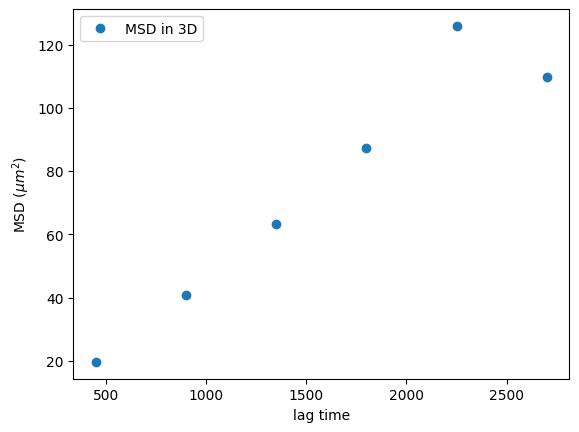

In [129]:
msd3D = tp.emsd(linked, mpp=1, fps=1/(7.50*60), pos_columns=["Xum","Yum","Zum"])
ax = msd3D.plot(style='o', label='MSD in 3D')
ax.set_ylabel(r'MSD ($\mu m^2$)')
ax.set_xlabel("lag time")
ax.legend(loc='upper left')
     

The diffusion constant is 0.01 μm²/s


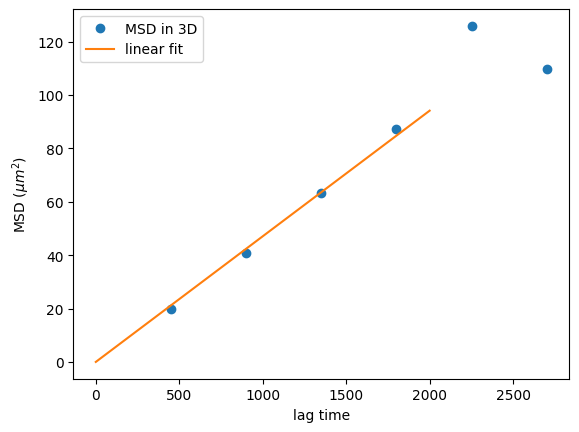

In [130]:
slope = np.linalg.lstsq(np.array(msd3D.index)[:, np.newaxis], msd3D)[0][0]

ax = msd3D.plot(style='o', label='MSD in 3D')
ax.plot(np.arange(2000), slope * np.arange(2000), label='linear fit')
ax.set_ylabel(r'MSD ($\mu m^2$)')
ax.set_xlabel("lag time")
ax.legend(loc='upper left')
print(r'The diffusion constant is {0:.2f} μm²/s'.format(slope / 6))

Our particules seems to follow a Brownian motion

### Btrack

Based on the signle example from their [website](https://btrack.readthedocs.io/en/latest/user_guide/simple_example.html).

As Btrack takes segmentated images, we can either create a tracking mask from our coordinates or maybe use the yen thresholding.

In [131]:
yen_vol = tifffile.memmap(C2_SEGMENTED_IMG_PATH)

path_config = Path(r"../../archives/btrack_models")

t, zlim, ylim,xlim = yen_vol.shape

In [132]:
scale = utils.get_pixel_size(C2_SEGMENTED_IMG_PATH)
scale = scale /scale.max()
scale

array([1.        , 0.26624843, 0.26624843])

In [133]:
objects = []

for idx, row in centers_cs.iterrows():
    obj = btrack.btypes.PyTrackObject()
    obj.t = int(row['T'])
    obj.x = float(row['X'])
    obj.y = float(row['Y'])
    obj.z = float(row['Z'])
    obj.ID = idx  # Original index for reference
    
    objects.append(obj)

with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(path_config /'particle_config.json')

    # append the objects to be tracked
    tracker.append(objects)

    # set the volume (Z axis volume limits default to [-1e5, 1e5] for 2D data)
    tracker.volume = ((0, xlim), (0, ylim), (0, zlim))

    tracker.max_search_radius = 100 #/ np.mean(resolution[1:])

    # track them (in interactive mode)
    tracker.track_interactive(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks as a python list
    tracks = tracker.tracks

    # optional: get the data in a format for napari
    data, properties, graph = tracker.to_napari()

    tracker.export(C2_BTRACK_IMG_PATH, obj_type='obj_type_1')

[INFO][2026/05/18 02:52:19 PM] Loaded btrack: C:\Users\voland\.conda\envs\stardist-env\Lib\site-packages\btrack\libs\libtracker.DLL
[INFO][2026/05/18 02:52:19 PM] Starting BayesianTracker session
[INFO][2026/05/18 02:52:19 PM] Loading configuration file: ..\..\archives\btrack_models\particle_config.json
[INFO][2026/05/18 02:52:19 PM] Objects are of type: <class 'list'>
[WARNING][2026/05/18 02:52:19 PM] `track_interactive` will be deprecated. Use `track` instead.
[INFO][2026/05/18 02:52:19 PM] Starting tracking... 
[INFO][2026/05/18 02:52:19 PM] Update using: ['MOTION']
[INFO][2026/05/18 02:52:19 PM] Tracking objects in frames 0 to 7 (of 7)...
[INFO][2026/05/18 02:52:19 PM]  - Timing (Bayesian updates: 4.00ms, Linking: 1.00ms)
[INFO][2026/05/18 02:52:19 PM]  - Probabilities (Link: 0.62364, Lost: 1.00000)
[INFO][2026/05/18 02:52:19 PM] SUCCESS.
[INFO][2026/05/18 02:52:19 PM]  - Found 95 tracks in 7 frames (in 0.0s)
[INFO][2026/05/18 02:52:19 PM]  - Inserted 3 dummy objects to fill tracki